In [1]:
import sys

sys.path.append('../')
from const import *
from train import *

In [2]:
with open('../models/2025-03-18_00-40-55/forecasts_8.pkl', 'rb') as f:
    forecasts = pickle.load(f)

forecasts = np.vstack(forecasts)
print(forecasts.shape)

(51963, 100, 84)


In [ ]:
for index in range(10):
    forecasts_percentile = [
        data[np.delete(np.arange(100), np.unique(np.where((data<np.percentile(data, 10-index, axis=0)) | (data>np.percentile(data, 90+index, axis=0)))[0])),:]
        for data in forecasts
    ]
    len_list = [len(data)for data in forecasts_percentile]
    if min(len_list)>10:
        print('Percentile = [%d, %d]'%(10-index, 90+index))
        break

In [3]:
forecasts_percentile = np.array([np.expm1(np.median(data, axis=0)) for data in forecasts])
forecasts_percentile = forecasts_percentile.reshape((51963, 12, -1)).sum(axis=2)

In [4]:
config = get_config()
train_dataset, val_dataset, predict_dataset = load_dataset(DATASET_WEEK_PATH)
train_dataloader, val_dataloader, predict_dataloader = get_dataloader(
    train_dataset, val_dataset, predict_dataset, config
)

In [5]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

def plot(ts_index):
    fig, ax = plt.subplots()

    index = pd.period_range(
        start=predict_dataset[ts_index][FieldName.START],
        periods=len(predict_dataset[ts_index][FieldName.TARGET]),
        freq=FREQ,
    ).to_timestamp()

    # Major ticks every half year, minor ticks every month,
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    ax.plot(
        #index[-2*PREDICTION_LENGTH:], 
        index[-65:], 
        #np.array(predict_dataset[ts_index]["target"][-65:]),
        np.expm1(predict_dataset[ts_index]["target"][-65:]),
        label="actual",
    )

    plt.plot(
        index[-PREDICTION_LENGTH:], 
        #np.array(np.median(forecasts[ts_index], axis=0)),
        forecasts_percentile[ts_index],
        label="median",
    )
    plt.legend()
    plt.show()

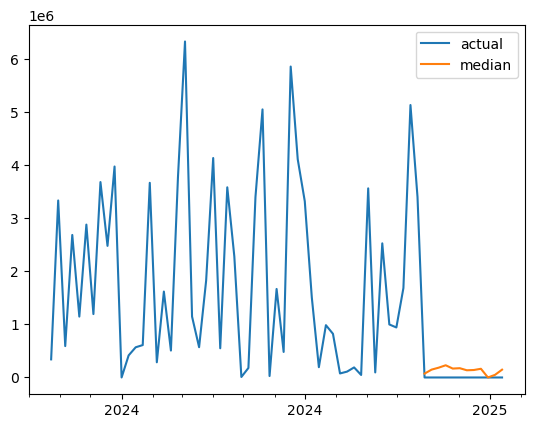

In [12]:
plot(5453)

In [3]:
config = get_config()
train_dataset, val_dataset, predict_dataset = load_dataset(DATASET_WEEK_PATH)
train_dataloader, val_dataloader, predict_dataloader = get_dataloader(
    train_dataset, val_dataset, predict_dataset, config
)
model_path = MODELS_PATH / '2025-03-06_22-45-11/checkpoint-epoch=26-train_loss=0.7764-sMAPE_vall=0.1453'
inference(model_path, train_dataloader, val_dataloader, config)

2025-03-07,15:23:42 Loading states from /mnt/data/ods/example/../models/2025-03-06_22-45-11/checkpoint-epoch=26-train_loss=0.7764-sMAPE_vall=0.1453
2025-03-07,15:23:42 All model weights loaded successfully
2025-03-07,15:23:42 All optimizer states loaded successfully
2025-03-07,15:23:42 All scheduler states loaded successfully
2025-03-07,15:23:42 All dataloader sampler states loaded successfully
2025-03-07,15:23:42 All random states loaded successfully
2025-03-07,15:23:42 Loading in 0 custom states
51it [02:39,  3.13s/it]
2025-03-07,15:26:22 Forecasts path: /mnt/data/ods/example/../models/2025-03-06_22-45-11/forecasts_26.pkl


In [206]:
config = get_config()
train_dataset, val_dataset, predict_dataset = load_dataset(DATASET_WEEK_PATH, add_val=True)
train_dataloader, val_dataloader, predict_dataloader = get_dataloader(
    train_dataset, val_dataset, predict_dataset, config
)

with open('../models/2025-03-11_20-24-45/forecasts_95.pkl', 'rb') as f:
    forecasts = pickle.load(f)

forecasts = np.vstack(forecasts)
print(forecasts.shape)

(51963, 100, 12)


In [207]:
for index in range(10):
    forecasts_percentile = [
        #np.median(data[np.delete(np.arange(100), np.unique(np.where((data<np.percentile(data, 5, axis=0)) | (data>np.percentile(data, 95, axis=0)))[0])),:], axis=0)
        data[np.delete(np.arange(100), np.unique(np.where((data<np.percentile(data, 10-index, axis=0)) | (data>np.percentile(data, 90+index, axis=0)))[0])),:]
        for data in forecasts
    ]
    len_list = [len(data)for data in forecasts_percentile]
    if min(len_list)>10:
        break
forecasts_percentile = [np.expm1(np.median(data, axis=0)) for data in forecasts]

In [208]:
np.array(forecasts_percentile).shape

(51963, 12)

In [132]:
forecast_median = np.median(forecasts, 1)
forecast_median = np.expm1(forecast_median)
forecast_median.mean()

3423882.2

In [197]:
for index in range(10):
    forecasts_percentile = [
        #np.median(data[np.delete(np.arange(100), np.unique(np.where((data<np.percentile(data, 5, axis=0)) | (data>np.percentile(data, 95, axis=0)))[0])),:], axis=0)
        data[np.delete(np.arange(100), np.unique(np.where((data<np.percentile(data, 10-index, axis=0)) | (data>np.percentile(data, 90+index, axis=0)))[0])),:]
        for data in forecasts
    ]
    len_list = [len(data)for data in forecasts_percentile]
    if min(len_list)>10:
        break

In [198]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

def plot(ts_index):
    fig, ax = plt.subplots()

    index = pd.period_range(
        start=val_dataset[ts_index][FieldName.START],
        periods=len(val_dataset[ts_index][FieldName.TARGET]),
        freq=FREQ,
    ).to_timestamp()

    # Major ticks every half year, minor ticks every month,
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    ax.plot(
        index[-PREDICTION_LENGTH-53:], 
        np.expm1(np.array(val_dataset[ts_index]["target"][-PREDICTION_LENGTH-53:])),
        label="actual",
    )

    plt.plot(
        index[-PREDICTION_LENGTH:], 
        np.expm1(np.median(forecasts[ts_index], axis=0)),
        #np.expm1(forecasts_percentile[ts_index]),
        #np.expm1(forecasts_percentile[ts_index][0]),
        #np.expm1(forecasts[ts_index][7]),
        label="median",
    )
    
    plt.fill_between(
        index[-PREDICTION_LENGTH:],
        np.expm1(forecasts[ts_index].mean(0)) - np.expm1(forecasts[ts_index].std(axis=0)), 
        np.expm1(forecasts[ts_index].mean(0)) + np.expm1(forecasts[ts_index].std(axis=0)), 
        alpha=0.3, 
        interpolate=True,
        label="+/- 1-std",
    )
    plt.legend()
    plt.show()

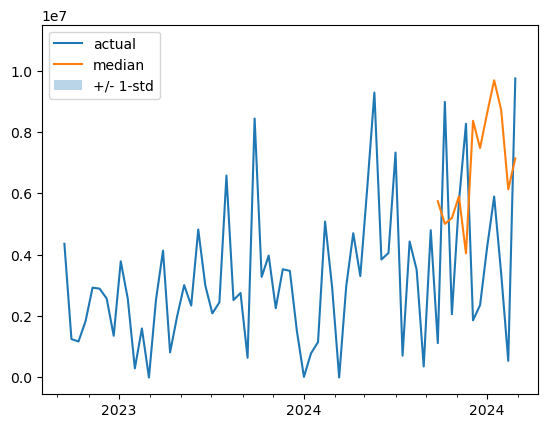

In [140]:
plot(565)

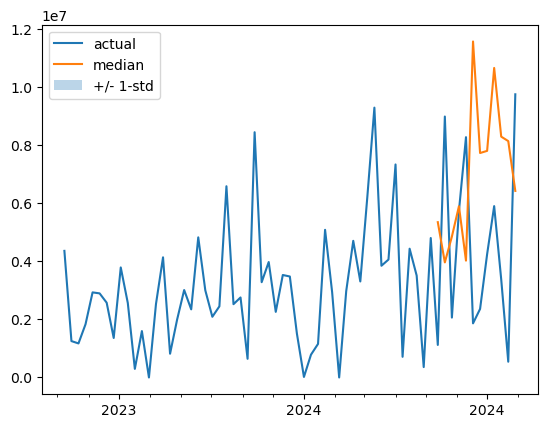

In [142]:
plot(565)

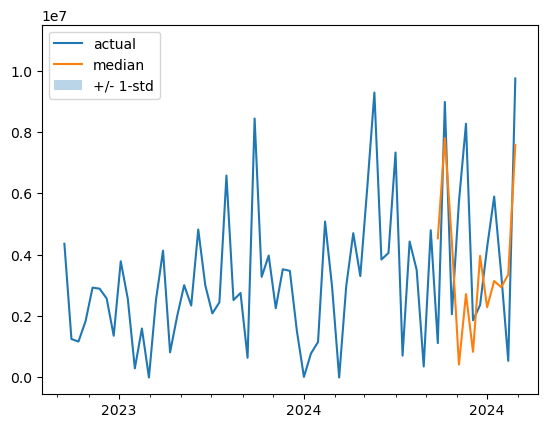

In [145]:
plot(565)

In [ ]:
config = get_config()
train_dataset, val_dataset, predict_dataset = load_dataset(DATASET_WEEK_PATH)
train_dataloader, val_dataloader, predict_dataloader = get_dataloader(
    train_dataset, val_dataset, predict_dataset, config
)
model_path = MODELS_PATH / '2025-03-06_22-45-11/checkpoint-epoch=26-train_loss=0.7764-sMAPE_vall=0.1453'
inference(model_path, train_dataloader, predict_dataloader, config)

In [1]:
import numpy as np

In [6]:
test = np.array([np.arange(24), np.arange(24)*2])

In [7]:
test

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23],
       [ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30,
        32, 34, 36, 38, 40, 42, 44, 46]])

In [10]:
test.reshape((2, 12,-1)) 

array([[[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17],
        [18, 19],
        [20, 21],
        [22, 23]],

       [[ 0,  2],
        [ 4,  6],
        [ 8, 10],
        [12, 14],
        [16, 18],
        [20, 22],
        [24, 26],
        [28, 30],
        [32, 34],
        [36, 38],
        [40, 42],
        [44, 46]]])